# Training

In [1]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, Concatenate, Add, Activation, Flatten, Dense, Concatenate
from tensorflow.keras.activations import relu, sigmoid
from tensorflow.keras.models import Model
from qkeras import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

2026-04-28 16:50:18.633877: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 16:50:18.635075: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 16:50:18.649641: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-28 16:50:18.649661: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-28 16:50:18.649672: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [2]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_OFFSET_X = -4
MAX_OFFSET_X = 4

MIN_OFFSET_Y = -4
MAX_OFFSET_Y = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

# params: [center_x, center_y, std_x, std_y, sin2theta, cos2theta, intensity]
scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, 1.0, 1.0, 1.0], dtype=np.float32)

SEED = 0
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

In [3]:
# Generate Gaussian Functions #

def img_gen(rng: np.random.Generator = rng) -> tuple:

    center_x = GAUSSIAN_X / 2 + rng.uniform(MIN_OFFSET_X, MAX_OFFSET_X)
    center_y = GAUSSIAN_Y / 2 + rng.uniform(MIN_OFFSET_Y, MAX_OFFSET_Y)

    std_x = rng.uniform(MIN_STD_X, MAX_STD_X)
    std_y = rng.uniform(MIN_STD_Y, MAX_STD_Y)
    theta = rng.uniform(MIN_THETA, MAX_THETA)

    intensity = MIN_INTENSITY + rng.random() * (MAX_INTENSITY - MIN_INTENSITY)

    shape_params = np.array([center_x, center_y, std_x, std_y, theta])
    gaussian = np.array(gaussian_gen(*shape_params))
    gaussian = gaussian * intensity * 255
    gaussian = gaussian.astype(np.uint8)

    # params: [cx, cy, sx, sy, sin(2*theta), cos(2*theta), intensity]
    params = np.array([center_x, center_y, std_x, std_y, np.sin(2*theta), np.cos(2*theta), intensity])
    return (gaussian, params)

X, Y = np.meshgrid(
    np.arange(GAUSSIAN_X),
    np.arange(GAUSSIAN_Y)
)
def gaussian_gen(center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y) -> np.ndarray:
    
    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, params: np.ndarray) -> None:
    
    img = np.squeeze(img)
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if params is not None:
        # params: [cx, cy, sx, sy, sin(2t), cos(2t), intensity]
        theta = 0.5 * np.arctan2(params[4], params[5])
        print(
        f"[(c_x, c_y)]: ({params[0]:.2f}, {params[1]:.2f}) "
        f"[(s_x, s_y)]: ({params[2]:.2f}, {params[3]:.2f}) "
        f"[Theta]: {theta:.2f} "
        f"[I]: {params[6]:.2f} "
        )
    
    plt.imshow(rgb_image)
    plt.axis('off')

[(c_x, c_y)]: (25.10, 22.16) [(s_x, s_y)]: (5.25, 5.10) [Theta]: -0.59 [I]: 0.75 


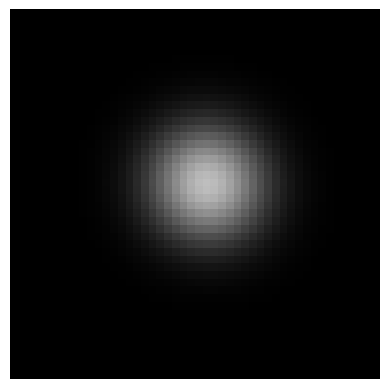

In [4]:
# Test Generate Functions #

img, params = img_gen()
img_visualization_one(img, params)

In [5]:
# Generate Training Dataset #
SAMPLE_COUNT = 10000
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing

img_arr = np.empty((SAMPLE_COUNT, GAUSSIAN_Y, GAUSSIAN_X, 1), dtype=np.float32)
label_arr = np.empty((SAMPLE_COUNT, 7), dtype=np.float32)

for i in tqdm(range(SAMPLE_COUNT)):
    img, label = img_gen()
    img_arr[i] = img.astype(np.float32) / 256.0             # Normalize values [0, 1)
    label_arr[i] = label.astype(np.float32) / scaling_arr   # Normalize values using scaling array

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 10000/10000 [00:00<00:00, 36038.40it/s]

[Images Shape]: (10000, 48, 48, 1)
[Labels Shape]: (10000, 7)


In [6]:
# Generate Validation Dataset for Training #
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing
VAL_COUNT = 1000


img_arr_val = np.empty((VAL_COUNT, GAUSSIAN_Y, GAUSSIAN_X, 1), dtype=np.float32)
label_arr_val = np.empty((VAL_COUNT, 7), dtype=np.float32)

for i in tqdm(range(VAL_COUNT)):
    img, label = img_gen()
    img_arr_val[i] = img.astype(np.float32) / 256.0             # Normalize values [0, 1)
    label_arr_val[i] = label.astype(np.float32) / scaling_arr   # Normalize values using scaling array

print(f'[Images Shape]: {img_arr_val.shape}')
print(f'[Labels Shape]: {label_arr_val.shape}')

100%|██████████| 1000/1000 [00:00<00:00, 34140.83it/s]

[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 7)


In [7]:
# Convert Data to TF Dataset #
BATCH_SIZE = 50

dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr, {'params': label_arr, 'reconstruction': img_arr})
    )
    .shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr_val, {'params': label_arr_val, 'reconstruction': img_arr_val})
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

2026-04-28 16:50:32.375106: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-28 16:50:32.378826: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# Qkeras Model Architecture #
TOTAL_BITS = 8
INTEGER_BITS = 0


w_quant = quantized_bits(TOTAL_BITS, INTEGER_BITS, symmetric=False, keep_negative=True, alpha=1)
relu_quant = quantized_relu(TOTAL_BITS, INTEGER_BITS)

input_layer = Input(shape=(GAUSSIAN_X, GAUSSIAN_Y, 1), name='InputLayer')

x = QConv2D(filters=4, kernel_size=3, strides=1, padding='valid', name='qconv1',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(input_layer)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn1')(x)
x = QActivation(relu_quant, name="qact1")(x)
x = MaxPool2D(pool_size=3, strides=3, name='pool1')(x)

x = QConv2D(filters=8, kernel_size=3, strides=1, padding='valid', name='qconv2',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn2')(x)
x = QActivation(relu_quant, name="qact2")(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool2')(x)

x = QConv2D(filters=12, kernel_size=3, strides=1, padding='valid', name='qconv3',
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03, name='bn3')(x)
x = QActivation(relu_quant, name="qact3")(x)
x = MaxPool2D(pool_size=2, strides=2, name='pool3')(x)

x = Flatten(name='flatten')(x)
x = Dense(units=20, activation='relu', name='fc1')(x)

# Split head to constrain outputs:
x_center    = Dense(units=2, activation='linear',   name='center')(x)
x_std       = Dense(units=2, activation='softplus', name='std')(x)
x_theta     = Dense(units=2, activation='linear',   name='theta')(x)
x_intensity = Dense(units=1, activation='sigmoid',  name='intensity')(x)

x_p1        = tf.keras.layers.Concatenate(axis=-1, name='params_1')([x_center, x_std])
x_p2        = tf.keras.layers.Concatenate(axis=-1, name='params_2')([x_theta, x_intensity])
x_params    = tf.keras.layers.Concatenate(axis=-1, name='params')([x_p1, x_p2])  # 7-dim

gaussian_qk = Model(inputs=input_layer, outputs=x_params, name='gaussian')

In [9]:
# Tensorflow Functions #

scaling_tf = tf.constant(scaling_arr, dtype=tf.float32)
X_mesh_tf, Y_mesh_tf = tf.meshgrid(
    tf.range(GAUSSIAN_X, dtype=tf.float32),
    tf.range(GAUSSIAN_Y, dtype=tf.float32),
)
X_mesh_tf = X_mesh_tf[tf.newaxis, :, :, tf.newaxis]
Y_mesh_tf = Y_mesh_tf[tf.newaxis, :, :, tf.newaxis]
def gaussian_gen_tf(params_norm):
    # params_norm ordering: [cx, cy, sx, sy, sin2t, cos2t, intensity]
    params = params_norm * scaling_tf
    cx  = tf.reshape(params[:, 0], (-1, 1, 1, 1))
    cy  = tf.reshape(params[:, 1], (-1, 1, 1, 1))
    sx  = tf.reshape(params[:, 2], (-1, 1, 1, 1))
    sy  = tf.reshape(params[:, 3], (-1, 1, 1, 1))
    s2t = tf.reshape(params[:, 4], (-1, 1, 1, 1))
    c2t = tf.reshape(params[:, 5], (-1, 1, 1, 1))
    ity = tf.reshape(params[:, 6], (-1, 1, 1, 1))

    norm = tf.sqrt(tf.square(s2t) + tf.square(c2t) + 1e-6)
    s2t = s2t / norm
    c2t = c2t / norm

    cos_sqr = 0.5 * (1.0 + c2t)
    sin_sqr = 0.5 * (1.0 - c2t)
    sin_cos = 0.5 * s2t

    std_x_sqrd = tf.square(sx) + 1e-6
    std_y_sqrd = tf.square(sy) + 1e-6

    a = (cos_sqr) / (2.0 * std_x_sqrd) + (sin_sqr) / (2.0 * std_y_sqrd)
    b = -1.0 * (sin_cos) / (2.0 * std_x_sqrd) + (sin_cos) / (2.0 * std_y_sqrd)
    c = (sin_sqr) / (2.0 * std_x_sqrd) + (cos_sqr) / (2.0 * std_y_sqrd)

    dx = X_mesh_tf - cx
    dy = Y_mesh_tf - cy
    return ity * tf.exp(-(a * tf.square(dx) + 2.0 * b * dx * dy + c * tf.square(dy)))

x_reconstruction = tf.keras.layers.Lambda(gaussian_gen_tf, name='reconstruction')(gaussian_qk.output)
training_model = Model(
    inputs=gaussian_qk.input,
    outputs=[gaussian_qk.output, x_reconstruction],
    name='gaussian_training',
)

BG_WEIGHT = 0.05
def recon_loss(y_true, y_pred):
    W = y_true + BG_WEIGHT
    return tf.reduce_mean(tf.reduce_sum(W * tf.square(y_true - y_pred), axis=[1, 2, 3]))

CIRCLE_WEIGHT = 0.1
def supervised_params_loss(y_true, y_pred):
    diff = y_true - y_pred
    unambiguous = tf.stack([diff[:, 0], diff[:, 1], diff[:, 6]], axis=-1)
    mse_unambiguous = tf.reduce_mean(tf.reduce_sum(tf.square(unambiguous), axis=-1))

    s2t = y_pred[:, 4]
    c2t = y_pred[:, 5]
    circle = tf.reduce_mean(tf.square(tf.square(s2t) + tf.square(c2t) - 1.0))

    return mse_unambiguous + CIRCLE_WEIGHT * circle

In [ ]:
# Train or Load #
TRAIN_MODEL = True
LOAD_MODEL = False

MODEL_NAME = '[Gaus]_[Generated]_[48]_Q.keras'
NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

LOSS_WEIGHTS = {'params': 10.0, 'reconstruction': 1.0}

if TRAIN_MODEL and LOAD_MODEL:
    print("Are you sure you want to Train & Load ?")

elif TRAIN_MODEL:
    adam_optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        global_clipnorm=1.0,
    )
    training_model.compile(
        optimizer=adam_optimizer,
        loss={'params': supervised_params_loss, 'reconstruction': recon_loss},
        loss_weights=LOSS_WEIGHTS,
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    history = training_model.fit(
        dataset,
        validation_data=val_dataset,
        epochs=NUM_EPOCHS,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

elif LOAD_MODEL:
    co = {}
    # co['loss_wbce'] = loss_wbce
    gaussian_qk = tf.keras.models.load_model(f'../Models/{MODEL_NAME}')

gaussian_qk.summary()

Epoch 1/100
200/200 [==============================] - 2s 3ms/step - loss: 6.3148 - params_loss: 0.1006 - reconstruction_loss: 5.3084 - val_loss: 0.9206 - val_params_loss: 0.0087 - val_reconstruction_loss: 0.8337 - lr: 0.0010
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.7540 - params_loss: 0.0059 - reconstruction_loss: 0.6945 - val_loss: 0.5678 - val_params_loss: 0.0044 - val_reconstruction_loss: 0.5238 - lr: 0.0010
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.6351 - params_loss: 0.0045 - reconstruction_loss: 0.5905 - val_loss: 0.5267 - val_params_loss: 0.0035 - val_reconstruction_loss: 0.4913 - lr: 0.0010
Epoch 4/100
200/200 [==============================] - 1s 3ms/step - loss: 0.5682 - params_loss: 0.0037 - reconstruction_loss: 0.5314 - val_loss: 0.4789 - val_params_loss: 0.0030 - val_reconstruction_loss: 0.4486 - lr: 0.0010
Epoch 5/100
200/200 [==============================] - 1s 3ms/step - loss: 0.5420 - params_loss:

In [11]:
# Save Model #
SAVE_MODEL = False

if SAVE_MODEL:
    gaussian_tf.save(f'../Models/{MODEL_NAME}', include_optimizer=False)

In [28]:
# Predict on Validation Set #
predictions_qk = gaussian_qk.predict(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_qk.shape}')

32/32 [==============================] - 0s 912us/step
[Validation Shape]: (1000, 48, 48, 1)
[Prediction Shape]: (1000, 7)


In [29]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

label_real = label_arr_val[index] * scaling_arr
pred_real = predictions_qk[index] * scaling_arr

# Recover theta from (sin2t, cos2t) via arctan2. Principal value in [-pi/2, pi/2],
# which is the correct equivalence class for the ellipse symmetry.
theta_label = 0.5 * np.arctan2(label_real[4], label_real[5])
theta_pred  = 0.5 * np.arctan2(pred_real[4],  pred_real[5])

print(
    f"[Label]      [(c_x, c_y)]: ({label_real[0]:6.2f}, {label_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({label_real[2]:6.2f}, {label_real[3]:6.2f}) "
    f"[Theta]: {theta_label:.2f} "
    f"[I]: {label_real[6]:.2f} "
)

print(
    f"[Prediction] [(c_x, c_y)]: ({pred_real[0]:6.2f}, {pred_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real[2]:6.2f}, {pred_real[3]:6.2f}) "
    f"[Theta]: {theta_pred:.2f} "
    f"[I]: {pred_real[6]:.2f} "
)

[Label]      [(c_x, c_y)]: ( 26.72,  21.62) [(s_x, s_y)]: ( 10.36,   9.32) [Theta]: -0.82 [I]: 0.71 
[Prediction] [(c_x, c_y)]: ( 27.01,  21.48) [(s_x, s_y)]: (  9.79,   9.85) [Theta]: 0.04 [I]: 0.70 


In [61]:
# Mean Squared Error (per column)
mse = np.mean(((label_arr_val * scaling_arr) - (predictions_qk * scaling_arr)) ** 2, axis=0)

# Mean Absolute Error (per column)
mae = np.mean(np.abs((label_arr_val * scaling_arr) - (predictions_qk * scaling_arr)), axis=0)
np.set_printoptions(suppress=True, precision=6)
print("MSE (per column):", mse)
print("MAE (per column):", mae)

MSE (per column): [0.105391 0.131005 1.934914 1.917961 0.519733 1.436404 0.00013 ]
MAE (per column): [0.223385 0.273435 0.987646 0.990579 0.654427 0.97486  0.008768]


# HLS4ML

In [27]:
# HLS4ML Config #
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(gaussian_qk, granularity='name', backend='Vitis')

config['Flows'] = ['vitis:fifo_depth_optimization']
hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

config['Model']['Strategy'] = 'Latency'
# config['Model']['PipelineStyle'] = 'pipeline'

config["Model"]["ReuseFactor"] = 8
for layer_cfg in config["LayerName"].values():
    if "ReuseFactor" in layer_cfg:
        layer_cfg["ReuseFactor"] = 8

pprint(config)

{'Flows': ['vitis:fifo_depth_optimization'],
 'LayerName': {'InputLayer': {'Precision': {'result': 'auto'}, 'Trace': False},
               'center': {'Precision': {'accum': 'auto',
                                        'bias': 'auto',
                                        'result': 'auto',
                                        'weight': 'auto'},
                          'ReuseFactor': 8,
                          'Trace': False},
               'center_linear': {'Precision': {'result': 'auto',
                                               'table': 'fixed<18,8,TRN,WRAP,0>'},
                                 'ReuseFactor': 8,
                                 'TableSize': 1024,
                                 'Trace': False},
               'fc1': {'Precision': {'accum': 'auto',
                                     'bias': 'auto',
                                     'result': 'auto',
                                     'weight': 'auto'},
                       'ReuseFactor': 8

/home/pujan/Research/Rheed-Gaussian/.venv/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [30]:
# Compile & Predict #
hls_model = hls4ml.converters.convert_from_keras_model(
    gaussian_qk,
    hls_config=config,
    output_dir='../gaussian_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    part='xcku035-fbva676-2-e',
    project_name='gaussian'
)

hls_model.compile()

predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, 7)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')


****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Sun Apr 26 06:37:23 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/pujan/Research/Rheed-Gaussian/gaussian_hls4ml/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project gaussian_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Opening solution '/home/pujan/Research/Rheed-Gaussian/gaussian_hls4ml/gaussian_prj'.
INFO: [HLS 200-1510] Running: set_top gaussian 
INFO: [HLS 200-1510] Running: add_files firmware/gaussian.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/gaussian.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb gaussian_test.cpp -cflags -std=c++0

In [38]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

label_real    = label_arr_val[index] * scaling_arr
pred_real_tf  = predictions_qk[index] * scaling_arr
pred_real_hls = predictions_hls4ml[index] * scaling_arr

theta_label    = 0.5 * np.arctan2(label_real[4],    label_real[5])
theta_pred_tf  = 0.5 * np.arctan2(pred_real_tf[4],  pred_real_tf[5])
theta_pred_hls = 0.5 * np.arctan2(pred_real_hls[4], pred_real_hls[5])

print(
    f"[Label]          [(c_x, c_y)]: ({label_real[0]:6.2f}, {label_real[1]:6.2f}) "
    f"[(s_x, s_y)]: ({label_real[2]:6.2f}, {label_real[3]:6.2f}) "
    f"[Theta]: {theta_label:.2f} "
    f"[I]: {label_real[6]:.2f} "
)

print(
    f"[Prediction TF]  [(c_x, c_y)]: ({pred_real_tf[0]:6.2f}, {pred_real_tf[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real_tf[2]:6.2f}, {pred_real_tf[3]:6.2f}) "
    f"[Theta]: {theta_pred_tf:.2f} "
    f"[I]: {pred_real_tf[6]:.2f} "
)

print(
    f"[Prediction HLS] [(c_x, c_y)]: ({pred_real_hls[0]:6.2f}, {pred_real_hls[1]:6.2f}) "
    f"[(s_x, s_y)]: ({pred_real_hls[2]:6.2f}, {pred_real_hls[3]:6.2f}) "
    f"[Theta]: {theta_pred_hls:.2f} "
    f"[I]: {pred_real_hls[6]:.2f} "
)

[Label]          [(c_x, c_y)]: ( 23.47,  20.15) [(s_x, s_y)]: (  6.21,   6.38) [Theta]: 1.50 [I]: 0.28 
[Prediction TF]  [(c_x, c_y)]: ( 23.34,  21.03) [(s_x, s_y)]: (  6.85,   6.84) [Theta]: -1.13 [I]: 0.28 
[Prediction HLS] [(c_x, c_y)]: ( 23.17,  20.51) [(s_x, s_y)]: (  7.01,   6.91) [Theta]: -1.13 [I]: 0.28 
